| Nhóm | Tên Thuộc Tính | Ý Nghĩa Chi Tiết | Tầm Quan Trọng Trong Phân Tích |
| ----- | :---: | ----- | ----- |
| **Thông tin khoản vay** | **loan\_amnt** | Số tiền mà người vay đăng ký xin vay. | Biến đầu vào cho bài toán Optimization. |
|  | **term** | Thời hạn trả nợ (36 hoặc 60 tháng). | Ảnh hưởng đến rủi ro và lãi suất. |
|  | **int\_rate** | Lãi suất của khoản vay (%). | **Biến mục tiêu** cho bài toán Tối ưu hóa. |
|  | **installment** | Số tiền phải trả hàng tháng. | Đánh giá áp lực tài chính lên người vay. |
|  | **grade** | Xếp hạng tín dụng của LendingClub (A-G). | Phản ánh mức độ rủi ro hệ thống định nghĩa. |
|  | **sub\_grade** | Xếp hạng chi tiết hơn của Grade (A1, A2...). | Dùng để phân loại khách hàng tinh vi hơn. |
|  | **issue\_d** | Tháng và năm khoản vay được giải ngân. | Phân tích biến động theo thời gian (Time-series). |
|  | **loan\_status** | Trạng thái khoản vay (Fully Paid, Charged Off). | **Biến mục tiêu** cho dự báo nợ xấu. |
|  | **purpose** | Mục đích vay (nợ thẻ, mua xe, sửa nhà...). | Phân nhóm hành vi khách hàng. |
|  | **title** | Tiêu đề khoản vay do khách hàng đặt. | **Dữ liệu cho NLP** để tìm thông tin ẩn. |
|  | **initial\_list\_status** | Trạng thái niêm yết ban đầu (Whole hoặc Fractional). | Cách thức huy động vốn cho khoản vay. |
| **Hồ sơ cá nhân** | **emp\_title** | Chức danh/Nghề nghiệp của người vay. | **Dữ liệu cho NLP** để đánh giá độ ổn định. |
|  | **emp\_length** | Thâm niên làm việc (0 đến 10+ năm). | Thâm niên càng cao rủi ro càng thấp. |
|  | **home\_ownership** | Tình trạng nhà ở (Thuê, Thế chấp, Sở hữu). | Tài sản đảm bảo ngầm cho uy tín. |
|  | **annual\_inc** | Thu nhập hàng năm của người vay. | Khả năng tài chính cốt lõi để trả nợ. |
|  | **verification\_status** | Trạng thái xác minh thu nhập. | Độ tin cậy của dữ liệu thu nhập khai báo. |
|  | **addr\_state** | Địa chỉ liên lạc. | Phân tích rủi ro theo vùng địa lý. |
|  | **zip\_code** | 3 chữ số đầu của mã bưu điện (được trích xuất từ addr\_state). | Phân tích rủi ro theo khu vực kinh tế. |
| **Lịch sử tín dụng** | **dti** | Tỉ lệ tổng nợ trên thu nhập hàng tháng. | Chỉ số quan trọng nhất dự báo khả năng vỡ nợ. |
|  | **earliest\_cr\_line** | Ngày mở tài khoản tín dụng đầu tiên. | Tính "độ tuổi" và kinh nghiệm dùng tín dụng. |
|  | **open\_acc** | Số lượng tài khoản tín dụng đang mở. | Quy mô sử dụng tín dụng hiện tại. |
|  | **pub\_rec** | Số lượng hồ sơ pháp lý xấu (kiện tụng...). | Dấu hiệu cảnh báo về tư cách đạo đức/pháp lý. |
|  | **revol\_bal** | Tổng số dư nợ tín dụng quay vòng. | Số tiền nợ thẻ tín dụng hiện có. |
|  | **revol\_util** | Tỉ lệ sử dụng hạn mức tín dụng (%). | Sử dụng quá sát hạn mức là dấu hiệu rủi ro cao. |
|  | **total\_acc** | Tổng số tài khoản tín dụng trong lịch sử. | Thể hiện mức độ hoạt động tín dụng tổng thể. |
|  | **mort\_acc** | Số lượng tài khoản thế chấp (nhà). | Kinh nghiệm quản lý các khoản nợ lớn. |
|  | **pub\_rec\_bankruptcies** | Số lần đã từng tuyên bố phá sản công khai. | Lịch sử mất khả năng thanh toán nghiêm trọng. |
| **Khác** | **application\_type** | Loại đơn (Cá nhân hoặc Đồng sở hữu). | Trách nhiệm pháp lý của khoản vay. |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import re

# **1. Data overview**



In [ ]:
df=pd.read_csv('/content/drive/MyDrive/lending_club_loan_cleaned.csv')

In [ ]:
print(df.shape)
df.head()
df.info()

(395219, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395219 entries, 0 to 395218
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             395219 non-null  float64
 1   term                  395219 non-null  object 
 2   int_rate              395219 non-null  float64
 3   grade                 395219 non-null  object 
 4   sub_grade             395219 non-null  object 
 5   home_ownership        395219 non-null  object 
 6   annual_inc            395219 non-null  float64
 7   verification_status   395219 non-null  object 
 8   issue_d               395219 non-null  object 
 9   loan_status           395219 non-null  object 
 10  purpose               395219 non-null  object 
 11  dti                   395219 non-null  float64
 12  earliest_cr_line      395219 non-null  object 
 13  open_acc              395219 non-null  float64
 14  pub_rec               395219 non-null  

# **2. Loan Performance Overview**

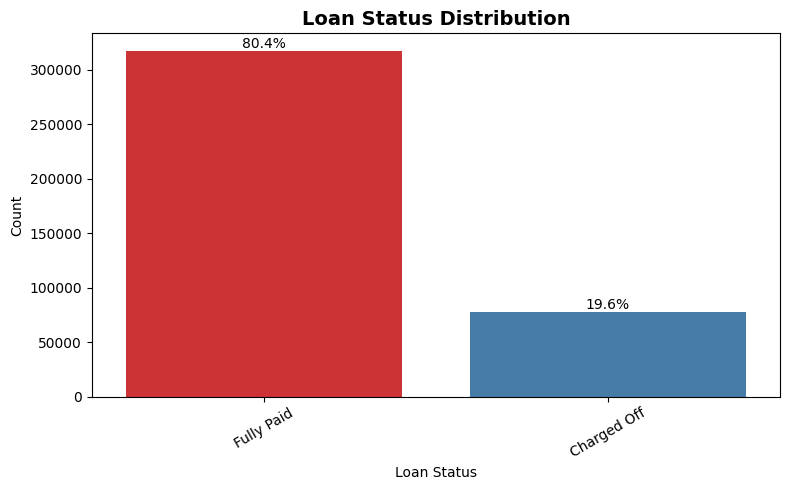

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='loan_status',
    hue='loan_status',
    order=df['loan_status'].value_counts().index,
    palette='Set1',
    legend=False
)

total = len(df)

for p in ax.patches:
    count = p.get_height()
    percent = 100 * count / total
    ax.annotate(f'{percent:.1f}%',
                (p.get_x() + p.get_width()/2, count),
                ha='center', va='bottom')

plt.title("Loan Status Distribution", fontsize=14, weight='bold')
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The overall loan performance indicates that the majority of loans are successfully repaid, with approximately 80% categorized as “Fully Paid” and around 20% as “Charged Off.” This suggests that the lending system is generally effective and profitable,however, the default rate remains relatively high compared to banking standards. This reflects the nature of the lending segment, which targets medium- to high-risk borrowers in exchange for higher interest rates. From a business perspective, this portfolio operates in a high-risk, high-return environment where managing default risk is critical to maintaining profitability.

# **3. Borrow Profile & Behaviour**

## 3.1. Overview Borrower Profile

In [ ]:
df.describe()

,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,cbrt_annual_inc,cbrt_open_acc,cbrt_revol_bal,cbrt_total_acc,cbrt_mort_acc
count,395219.000000,395219.000000,3.952190e+05,395219.000000,395219.000000,395219.000000,3.952190e+05,395219.000000,395219.000000,395219.000000,395219.000000,395219.000000,395219.000000,395219.000000,395219.000000,395219.000000
mean,14122.061250,13.642094,7.419937e+04,17.390758,11.318494,0.178481,1.585165e+04,53.808764,25.426505,1.787103,0.121722,40.632695,2.196469,22.809632,2.867940,0.853650
std,8357.054944,4.472944,6.155725e+04,18.032696,5.134901,0.531098,2.058427e+04,24.440088,11.885322,2.066011,0.356273,7.361480,0.329396,7.358588,0.462786,0.691485
min,500.000000,5.320000,0.000000e+00,0.000000,1.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.259921,0.000000
25%,8000.000000,10.490000,4.500000e+04,11.300000,8.000000,0.000000,6.038000e+03,35.900000,17.000000,0.000000,0.000000,35.568933,2.000000,18.209487,2.571282,0.000000
50%,12000.000000,13.330000,6.400000e+04,16.920000,10.000000,0.000000,1.119000e+04,54.800000,24.000000,1.000000,0.000000,40.000000,2.154435,22.367118,2.884499,1.000000
75%,20000.000000,16.550000,9.000000e+04,22.990000,14.000000,0.000000,1.962600e+04,72.900000,32.000000,3.000000,0.000000,44.814047,2.410142,26.973912,3.174802,1.442250
max,40000.000000,30.990000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000,205.722865,4.481405,120.352344,5.325074,3.239612


We will initiate with a comprehensive data profiling to identify and prioritize the high-impact variables that will drive our core analysis.

In [ ]:
print("Average Income:", df['annual_inc'].mean())
print("Median Loan Amount:", df['loan_amnt'].median())
print("Interest Rate Range:", df['int_rate'].min(), "-", df['int_rate'].max())
print("Median Interest Rate Range:", df['int_rate'].median())

top_purpose = df['purpose'].value_counts().head(3)
print(top_purpose)

Average Income: 74199.3724258955
Median Loan Amount: 12000.0
Interest Rate Range: 5.32 - 30.99
Median Interest Rate Range: 13.33
purpose
debt_consolidation    234169
credit_card            82923
home_improvement       23961
Name: count, dtype: int64


Basic Borrower Profile

The typical borrower has an average annual income of approximately $74,199  indicating a middle-income customer segment. The median loan amount is 12,000, suggesting that most borrowers take relatively small to medium-sized loans rather than large financing.

Interest rates range widely from 5.32% to 30.99%, reflecting a mix of borrower risk levels, though most likely fall in the mid-range. In terms of purpose, the majority of loans are used for debt consolidation and credit card repayment, showing that borrowers primarily seek to manage existing debt rather than fund new expenditures.




## 3.2. What is the most common loan amount among borrowers?

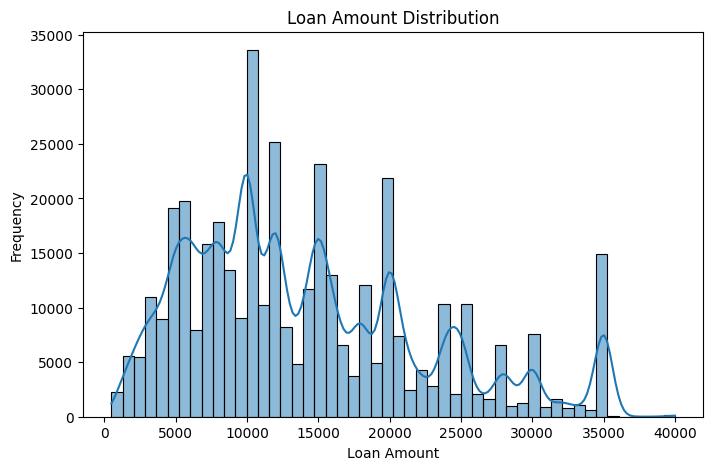

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['loan_amnt'], bins=50, kde=True)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

**Loan Amount**

The loan amount distribution shows a strong concentration between 5000 and 20,000, with a median of $12,000. This indicates that most loans are relatively small and used for short- to medium-term financial needs. The pattern confirms that the platform mainly focuses on consumer lending rather than large-scale financing.

## 3.3. What is the income distribution among borrowers?

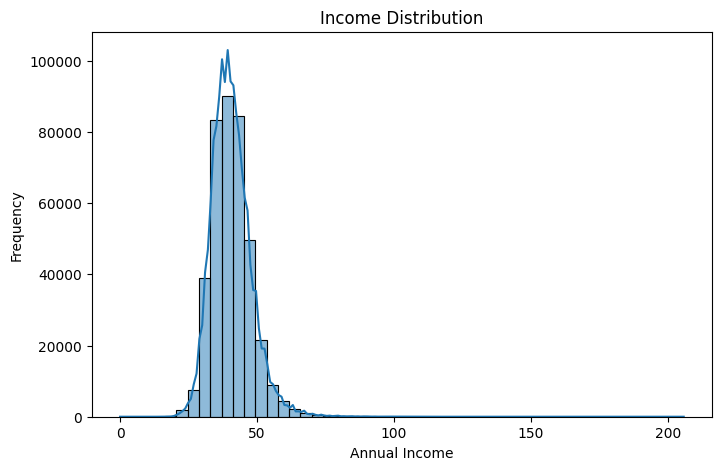

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['cbrt_annual_inc'], bins=50, kde=True)

plt.title("Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()

The distribution of cbrt_annual_inc appears approximately symmetric and bell-shaped, with most values concentrated around 35–50. Compared to the original income distribution, the cube root transformation has effectively reduced right skewness and compressed extreme high-income outliers, resulting in a more normal-like distribution.

The plot also indicates that most borrowers fall within the middle-income range, with a small number of high-income outliers. The average income is around $74,000, suggesting a relatively stable but not affluent customer base. This implies that the platform primarily serves middle-class individuals rather than high-net-worth clients.

## 3.4. What are the most common purposes for taking out a loan?

In [ ]:
purpose_counts = df['purpose'].value_counts()
print(purpose_counts.head())

purpose
debt_consolidation    234169
credit_card            82923
home_improvement       23961
other                  21059
major_purchase          8756
Name: count, dtype: int64


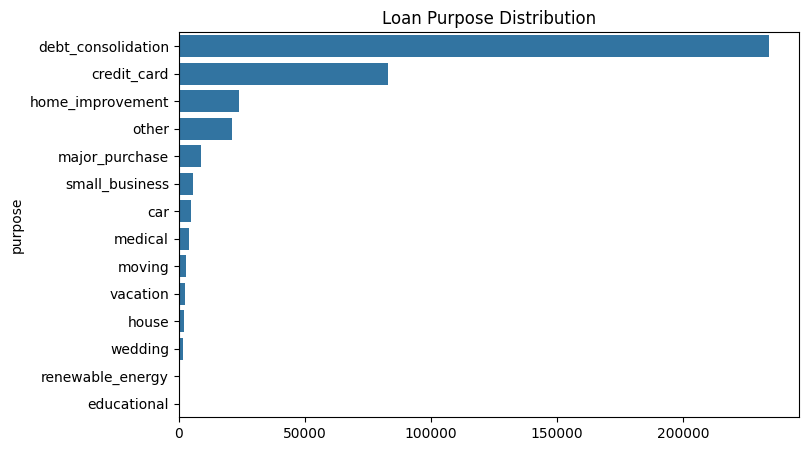

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=purpose_counts.values, y=purpose_counts.index)
plt.title("Loan Purpose Distribution")
plt.show()

The bar chart shows that debt consolidation is the most common purpose with more than 200,000 borrowers, followed by credit card repayment and home improvement. This indicates that borrowers are primarily using loans to manage existing debt rather than for new investments. It also highlights underlying financial pressure among customers.

## 3.5. Do higher-income borrowers tend to take larger loans?

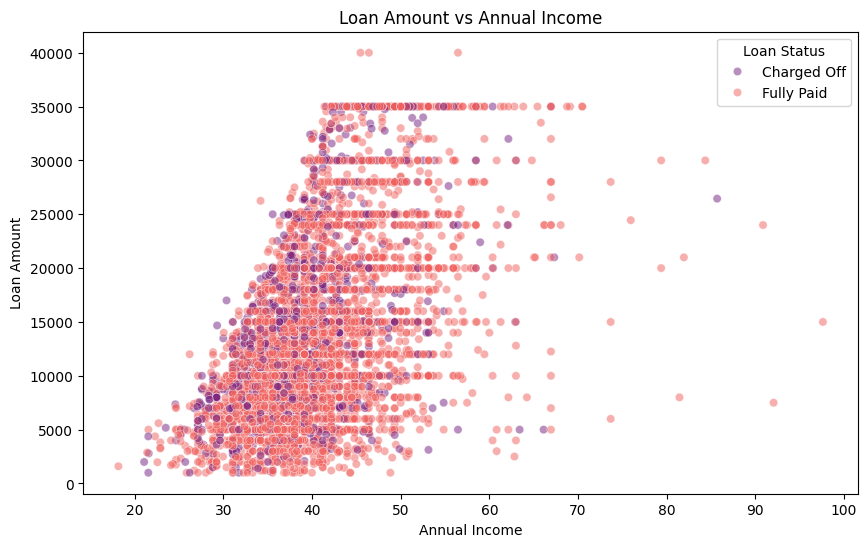

In [ ]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='cbrt_annual_inc',
    y='loan_amnt',
    hue='loan_status',
    alpha=0.5,
    palette='magma'
)
plt.title("Loan Amount vs Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.legend(title='Loan Status')
plt.show()

Loan Amount vs Income

The scatter plot shows a slight positive relationship between income and loan amount, where higher-income borrowers tend to take somewhat larger loans. However, most data points are concentrated in the lower income range, indicating limited variation in borrowing behavior. This suggests that income alone does not strongly determine loan size.

## 3.6. How does loan amount vary across different loan purposes?

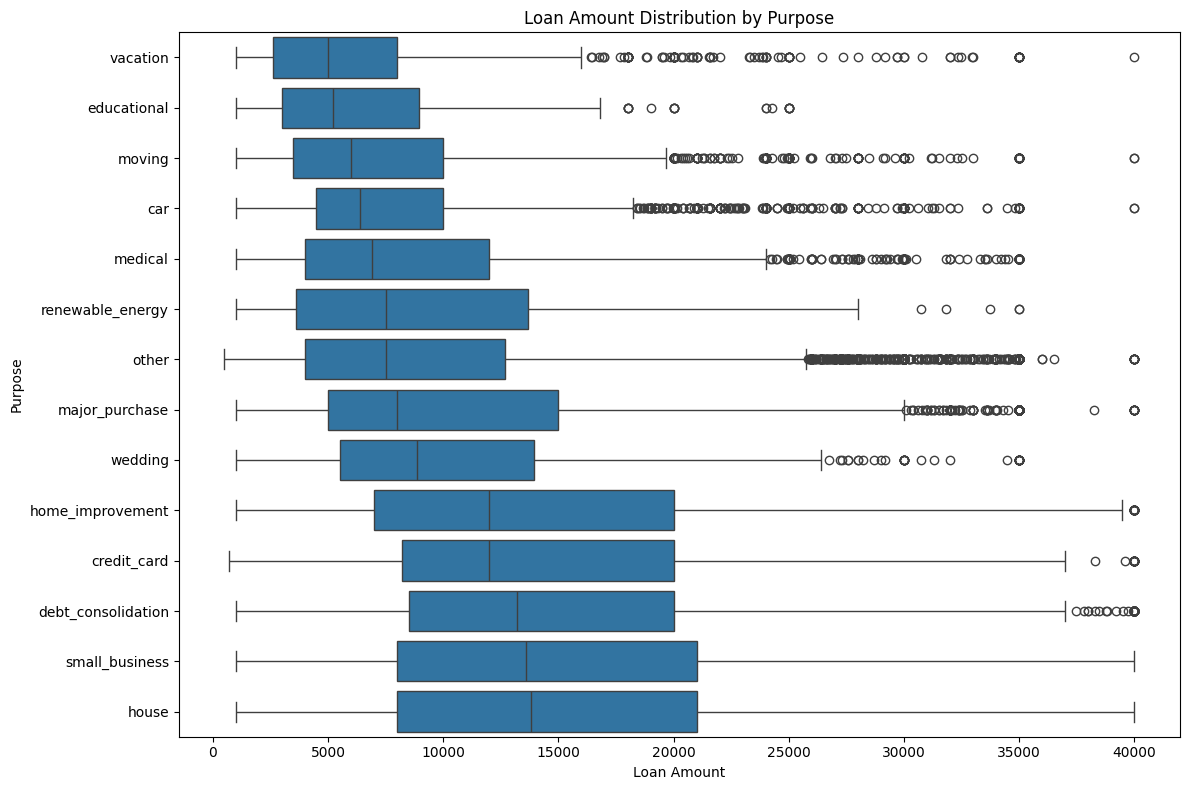

In [ ]:
plt.figure(figsize=(12,8))

# Sort theo median loan amount
order = df.groupby('purpose')['loan_amnt'].median().sort_values().index

sns.boxplot(
    data=df,
    y='purpose',
    x='loan_amnt',
    order=order
)

plt.title("Loan Amount Distribution by Purpose")
plt.xlabel("Loan Amount")
plt.ylabel("Purpose")

plt.tight_layout()
plt.show()

Loan Amount by Purpose

The boxplot indicates that loan amounts vary across purposes, with higher values observed in categories like small business and home improvement. In contrast, purposes such as vacation and medical tend to have smaller loan sizes. This reflects different financial needs and borrowing patterns depending on the loan purpose.

## **Borrower Profile & Behaviour:**

- Income & Risk: Middle-income (average of $74k/year) falling into the medium-risk category (interest rates of 10%–20%).

- Borrowing Behavior: **Moderate loans** (median $12k) primarily used for debt consolidation and credit card repayment.

- Financial Health: Currently under moderate financial pressure; borrowing to restructure existing debt rather than funding new investments.

Summary: This profile represents stable earners caught in a debt cycle, seeking loans as a strategic tool to manage cash flow and relieve financial strain.

# **4. Key drivers to risk analysis**



In [ ]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

df['default_flag'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

print(df.shape)
df.head()

(395219, 29)


,loan_amnt,term,int_rate,grade,sub_grade,home_ownership,annual_inc,verification_status,issue_d,loan_status,...,application_type,mort_acc,pub_rec_bankruptcies,address,cbrt_annual_inc,cbrt_open_acc,cbrt_revol_bal,cbrt_total_acc,cbrt_mort_acc,default_flag
0,10000.0,36 months,11.44,B,B4,RENT,117000.0,Not Verified,Jan-2015,Fully Paid,...,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690",48.909732,2.519842,33.131705,2.924018,0.00000,0
1,8000.0,36 months,11.99,B,B5,MORTGAGE,65000.0,Not Verified,Jan-2015,Fully Paid,...,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113",40.207258,2.571282,27.203312,3.000000,1.44225,0
2,15600.0,36 months,10.49,B,B3,RENT,43057.0,Source Verified,Jan-2015,Fully Paid,...,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113",35.049454,2.351335,22.886014,2.962496,0.00000,0
3,7200.0,36 months,6.49,A,A2,RENT,54000.0,Not Verified,Nov-2014,Fully Paid,...,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813",37.797631,1.817121,17.621736,2.351335,0.00000,0
4,24375.0,60 months,17.27,C,C5,MORTGAGE,55000.0,Verified,Apr-2013,Charged Off,...,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650",38.029525,2.351335,29.077084,3.503398,1.00000,1


The dataset was cleaned by filtering only clear loan outcomes (“Fully Paid” and “Charged Off”) to ensure a well-defined target variable. A binary variable default_flag was then created, mapping default cases to 1 and non-default to 0. This step is essential for transforming the problem into a supervised classification task.

## 4.1. Overview of numerical variables correlation

<Figure size 1000x600 with 0 Axes>

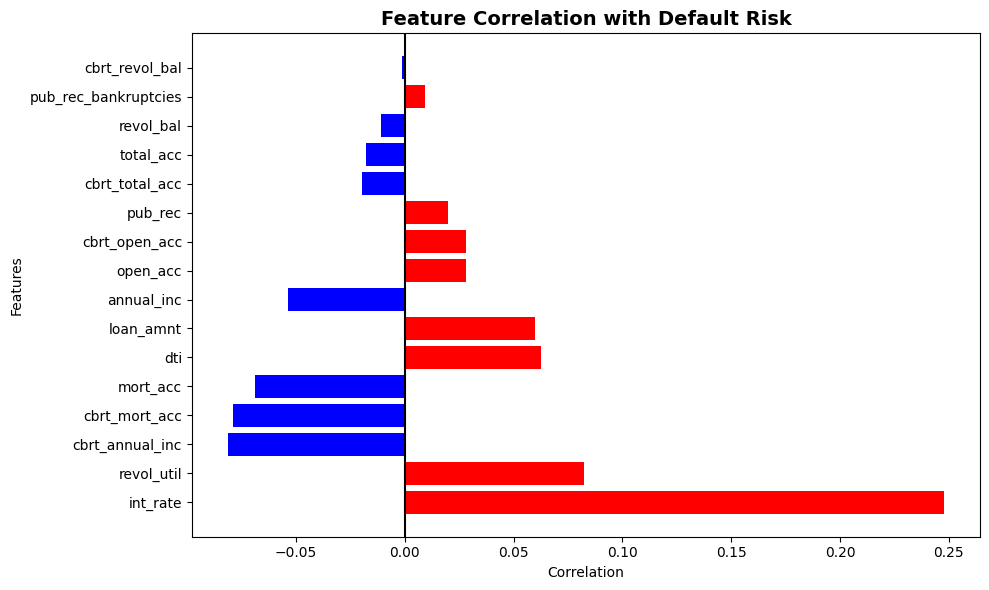

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_with_target = df[numeric_cols].corr()['default_flag'].drop('default_flag')
corr_sorted = corr_with_target.sort_values(key=abs, ascending=False)

plt.figure(figsize=(10,6))

colors = ['red' if x > 0 else 'blue' for x in corr_sorted.values]

plt.figure(figsize=(10,6))
plt.barh(corr_sorted.index, corr_sorted.values, color=colors)

plt.title("Feature Correlation with Default Risk", fontsize=14, weight='bold')
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.axvline(0, color='black')
plt.tight_layout()
plt.show()

**Numerical variables correlation**

The plot indicates that most variables have low correlation coefficients, suggesting weak linear relationships and low multicollinearity across features. The most correlated is between interest rate and the possibility of default.
Importantly, key variables like loan amount, income, and DTI do not show strong pairwise correlations, implying that default risk is likely driven by a combination of factors rather than a single dominant variable.

## **4.2. Borrower Profile & Default Risk Analysis**

### 4.2.1. Do customers with lower income have a higher default rate?

/tmp/ipykernel_5242/206654989.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default = df.groupby('income_group')['default_flag'].mean()


income_group
Low          0.240874
Medium       0.208706
High         0.181925
Very High    0.150083
Name: default_flag, dtype: float64


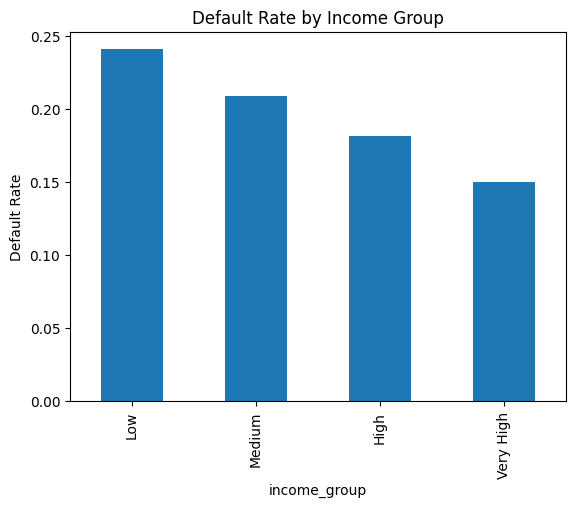

In [ ]:
df['income_group'] = pd.qcut(df['annual_inc'], 4,
                            labels=['Low','Medium','High','Very High'])

income_default = df.groupby('income_group')['default_flag'].mean()

print(income_default)

income_default.plot(kind='bar')
plt.title("Default Rate by Income Group")
plt.ylabel("Default Rate")
plt.show()

**Default Rate by Income**

Default rates decrease as income increases, from approximately 24% in the lowest income group to around 15% in the highest group. This inverse relationship confirms that higher income provides better financial resilience and repayment ability. However, the difference is not extreme, suggesting that income alone is insufficient and must be combined with other indicators like DTI.

### 4.2.2. How does debt-to-income ratio (DTI) affect default risk?

dti_group
Low            0.139912
Medium-Low     0.169137
Medium-High    0.203008
High           0.272683
Name: default_flag, dtype: float64


/tmp/ipykernel_5242/3484551308.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dti_default = df.groupby('dti_group')['default_flag'].mean()


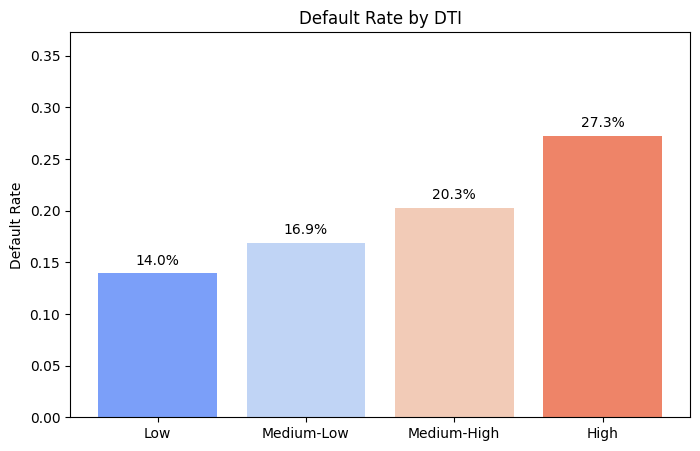

In [ ]:
dti_labels = ['Low', 'Medium-Low', 'Medium-High', 'High']
df['dti_group'] = pd.qcut(df['dti'], 4, labels=dti_labels)


dti_default = df.groupby('dti_group')['default_flag'].mean()

print(dti_default)

plt.figure(figsize=(8,5))
colors = sns.color_palette("coolwarm", n_colors=len(dti_default))
bars = plt.bar(dti_default.index, dti_default, color=colors)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f'{height*100:.1f}%',
             ha='center', va='bottom', fontsize=10)

plt.title("Default Rate by DTI")
plt.ylabel("Default Rate")
plt.ylim(0, dti_default.max() + 0.1)
plt.show()

Default Rate by DTI

Default rates increase sharply from around 14% in the lowest DTI group to approximately 27% in the highest group. This strong upward trend indicates that borrowers with higher debt relative to income are significantly more likely to default. DTI emerges as one of the most powerful predictors of credit risk, as it directly captures financial pressure and repayment capacity.

### 4.2.3. Does credit history length impact loan repayment behavior?

/tmp/ipykernel_5242/1901361903.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], errors='coerce')


  credit_age_group  default_rate  loan_count
0      10-15 years      0.252594        2217
1      15-20 years      0.238193       36672
2      20-25 years      0.208472      112629
3      25-30 years      0.190469      118618
4      30-40 years      0.176511       98181
5      40-50 years      0.173664       22532
6      50-65 years      0.206654        4268


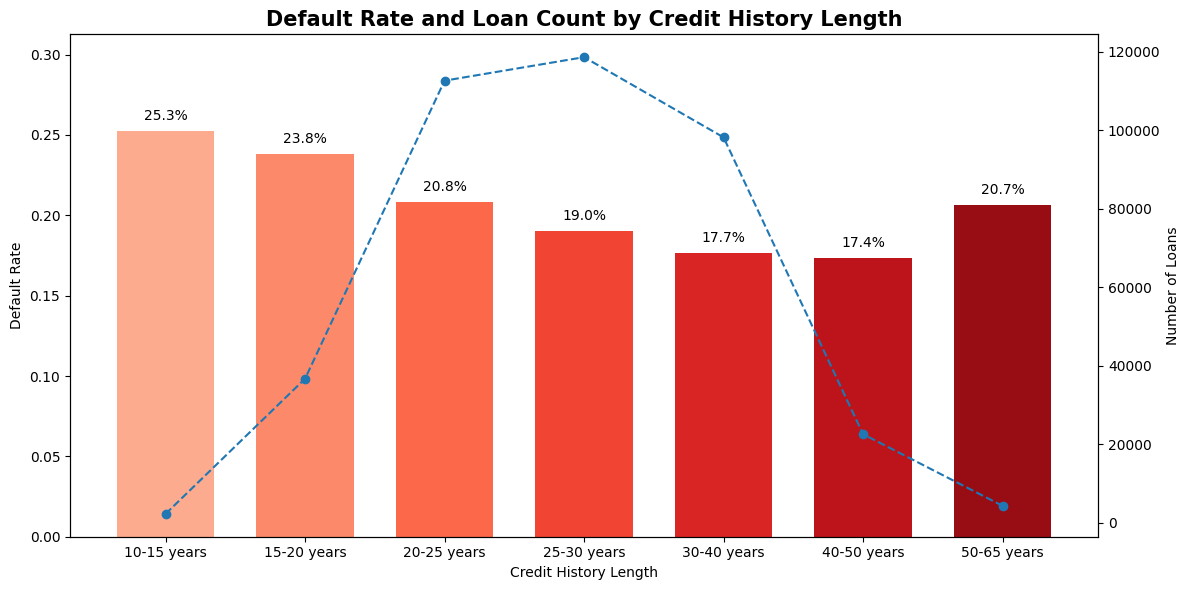

In [ ]:
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], errors='coerce')
df['credit_age'] = (pd.Timestamp.today() - df['earliest_cr_line']).dt.days / 365

bins = [0, 5, 10, 15, 20, 25, 30, 40, 50, 65]
labels = [
    '0-5 years', '5-10 years', '10-15 years', '15-20 years',
    '20-25 years', '25-30 years', '30-40 years', '40-50 years', '50-65 years'
]

df['credit_age_group'] = pd.cut(df['credit_age'], bins=bins, labels=labels, right=False)

credit_summary = (
    df.groupby('credit_age_group', observed=True)
      .agg(
          default_rate=('default_flag', 'mean'),
          loan_count=('default_flag', 'count')
      )
      .reset_index()
)

print(credit_summary)
fig, ax1 = plt.subplots(figsize=(12, 6))


colors = sns.color_palette("Reds", n_colors=len(credit_summary) + 2)[2:]


bars = ax1.bar(
    credit_summary['credit_age_group'],
    credit_summary['default_rate'],
    color=colors,
    width=0.7
)

ax1.set_title("Default Rate and Loan Count by Credit History Length", fontsize=15, weight='bold')
ax1.set_xlabel("Credit History Length")
ax1.set_ylabel("Default Rate")
ax1.set_ylim(0, credit_summary['default_rate'].max() + 0.06)


for bar, rate in zip(bars, credit_summary['default_rate']):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{rate*100:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )


ax2 = ax1.twinx()
ax2.plot(
    credit_summary['credit_age_group'],
    credit_summary['loan_count'],
    marker='o',
    linestyle='--'
)
ax2.set_ylabel("Number of Loans")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Credit History Length:
The default rate across credit history length follows a non-linear (U-shaped) pattern, where borrowers with a moderate credit history (around 20–40 years) exhibit the lowest risk. In contrast, both very short and very long credit histories are associated with higher default rates. This indicates that a longer credit history does not necessarily imply lower risk, and lenders should carefully assess these segments rather than relying solely on credit history length.

### 4.2.4. Which loan purposes are more likely to default?

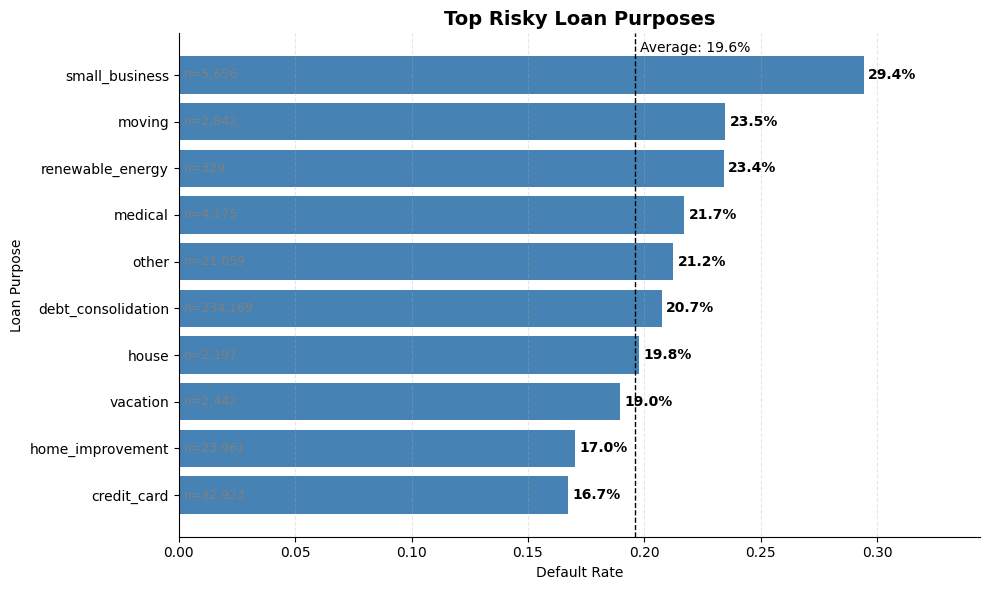

In [ ]:
# ===== Top 10 =====
purpose_default = (
    df.groupby('purpose')['default_flag']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

purpose_count = df['purpose'].value_counts().loc[purpose_default.index]

# ===== Plot =====
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

bars = plt.barh(
    purpose_default.index,
    purpose_default.values,
    color='steelblue'
)

plt.gca().invert_yaxis()

# ===== % label =====
for bar, rate in zip(bars, purpose_default.values):
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{rate*100:.1f}%",
        va='center',
        fontsize=10,
        weight='bold'
    )

# ===== count label =====
for bar, count in zip(bars, purpose_count.values):
    plt.text(
        0.002,
        bar.get_y() + bar.get_height()/2,
        f"n={count:,}",
        va='center',
        fontsize=9,
        color='gray'
    )

# ===== average line =====
avg_default = df['default_flag'].mean()

plt.axvline(
    avg_default,
    color='black',
    linestyle='--',
    linewidth=1
)

plt.text(
    avg_default + 0.002,
    -0.5,
    f"Average: {avg_default*100:.1f}%",
    fontsize=10
)

# ===== style =====
plt.title("Top Risky Loan Purposes", fontsize=14, weight='bold')
plt.xlabel("Default Rate")
plt.ylabel("Loan Purpose")

sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.xlim(0, purpose_default.max() + 0.05)

plt.tight_layout()
plt.show()

Default Rate by Purpose

The chart shows that default rates vary significantly by loan purpose, with an average of 19.6%. High-risk categories such as small business (29.4%), moving (23.5%), and renewable energy (23.4%) exceed the average, while credit card (16.7%) and home improvement (17.0%) are relatively safer.

### 4.2.5. How does default risk differ between types of home ownership?

  home_ownership  default_rate  loan_count
0            ANY      0.000000           3
3          OTHER      0.145455         110
1       MORTGAGE      0.169572      198022
4            OWN      0.206745       37660
5           RENT      0.226701      159395
2           NONE      0.241379          29


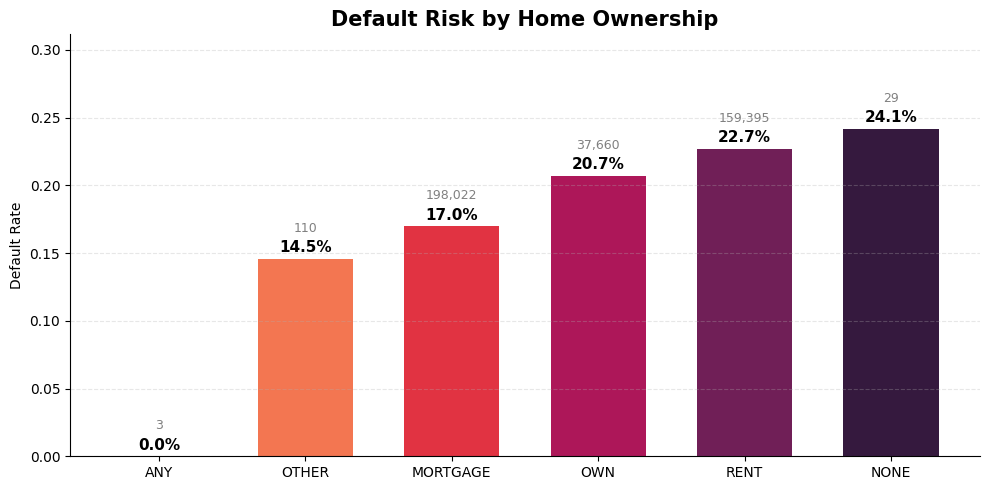

In [ ]:
home_summary = (
    df.groupby('home_ownership', observed=True)
      .agg(
          default_rate=('default_flag', 'mean'),
          loan_count=('default_flag', 'count')
      )
      .reset_index()
      .sort_values('default_rate')
)

print(home_summary)
plt.figure(figsize=(10,5))


colors = sns.color_palette("rocket_r", len(home_summary))

bars = plt.bar(
    home_summary['home_ownership'],
    home_summary['default_rate'],
    color=colors,
    width=0.65
)


for bar, rate in zip(bars, home_summary['default_rate']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{rate*100:.1f}%",
        ha='center',
        fontsize=11,
        weight='bold'
    )


for bar, count in zip(bars, home_summary['loan_count']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{count:,}",
        ha='center',
        fontsize=9,
        color='gray'
    )

plt.title("Default Risk by Home Ownership", fontsize=15, weight='bold')
plt.xlabel("")
plt.ylabel("Default Rate")

plt.ylim(0, home_summary['default_rate'].max() + 0.07)


sns.despine()

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Home Ownership:
The chart shows that borrowers who do not own a home or are renting (NONE, RENT) have significantly higher default rates compared to those who own a home or are paying a mortgage (OWN, MORTGAGE). This suggests that asset ownership, particularly housing, plays an important role in reducing credit risk. In contrast, individuals without collateral tend to have less financial stability, leading to a higher likelihood of default.

### **Borrower profile likely to default**
- Borrowers with low income (annual_inc) exhibit the highest default rates, while higher-income groups show better repayment capacity; however, income alone is not a strong standalone predictor.

- Individuals with high debt-to-income ratios (dti) are significantly more likely to default, highlighting financial stress as a core characteristic of risky borrowers.

- Borrowers with non-optimal credit history length (credit_age / earliest_cr_line) show a U-shaped risk pattern, where both very new and very old credit profiles carry higher default probability.

- In terms of home ownership (home_ownership), renters tend to have higher default proportions compared to mortgage holders or owners, reflecting lower asset stability.




## **4.3. Loan Structure & Default Risk Analysis**

### 4.3.1. Does interest rate influence the likelihood of default?

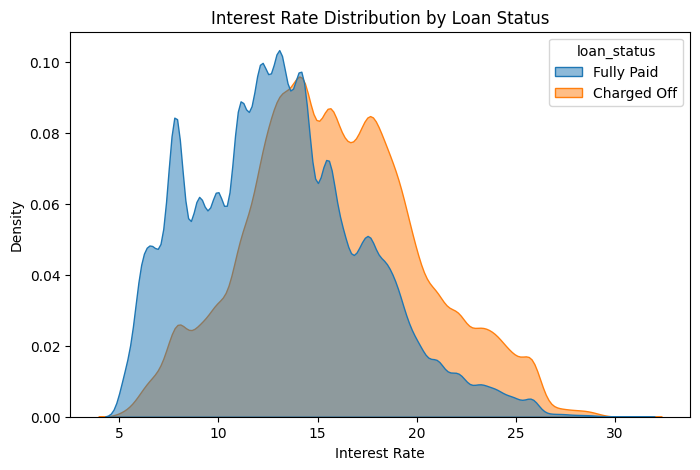

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x='int_rate',
    hue='loan_status',
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.title("Interest Rate Distribution by Loan Status")
plt.xlabel("Interest Rate")
plt.ylabel("Density")

plt.show()


**Interest Rate**

The distribution shows a clear shift between the two groups: Fully Paid loans are concentrated at lower interest rates (around 8%–15%), while Charged Off loans are more common at higher rates (15%–25%). The default distribution is also wider and more skewed toward higher values. This suggests that interest rate is a strong indicator of risk, as higher rates are associated with a higher probability of default.

/tmp/ipykernel_5242/3704983149.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bins = df.groupby('int_group')['int_rate'].agg(['min', 'max']).reset_index()


  int_group  default_rate  loan_count
0     5-10%      0.080436      100042
1    11-13%      0.152388       99063
2    13-17%      0.222610       99928
3    17-31%      0.334092       96186


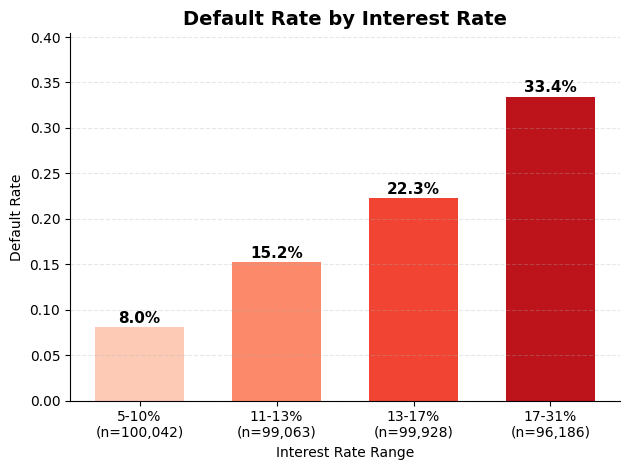

In [ ]:
df['int_group'] = pd.qcut(df['int_rate'], 4)

bins = df.groupby('int_group')['int_rate'].agg(['min', 'max']).reset_index()

labels = [
    f"{round(row['min'])}-{round(row['max'])}%"
    for _, row in bins.iterrows()
]

df['int_group'] = pd.qcut(df['int_rate'], 4, labels=labels)
int_summary = (
    df.groupby('int_group', observed=True)
      .agg(
          default_rate=('default_flag', 'mean'),
          loan_count=('default_flag', 'count')
      )
      .reset_index()
      .sort_values('default_rate')
)

print(int_summary)
colors = sns.color_palette("Reds", len(int_summary))

bars = plt.bar(
    int_summary['int_group'],
    int_summary['default_rate'],
    color=colors,
    width=0.65
)

# % label
for bar, rate in zip(bars, int_summary['default_rate']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{rate*100:.1f}%",
        ha='center',
        fontsize=11,
        weight='bold'
    )

labels = [
    f"{grp}\n(n={cnt:,})"
    for grp, cnt in zip(int_summary['int_group'], int_summary['loan_count'])
]

plt.xticks(range(len(labels)), labels)

plt.title("Default Rate by Interest Rate", fontsize=14, weight='bold')
plt.xlabel("Interest Rate Range")
plt.ylabel("Default Rate")

plt.ylim(0, int_summary['default_rate'].max() + 0.07)

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Default Rate by Interest Rate**

Higher interest rate groups show noticeably higher default rates, confirming that risk-based pricing aligns with actual borrower risk. However, this also suggests a potential feedback effect, where high interest rates increase repayment burden and further elevate default risk. Therefore, excessively high rates may not always be optimal, as they can push already risky borrowers into default.

### 4.3.2. Are larger loan amounts associated with higher default rates?

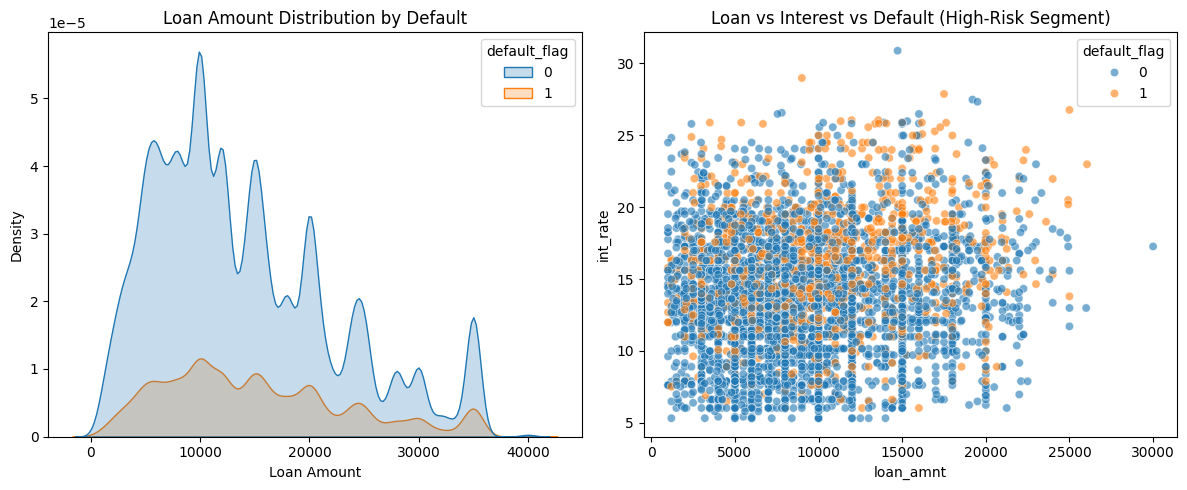

In [ ]:
plt.figure(figsize=(12,5))

# 🔹 1.
plt.subplot(1,2,1)
sns.kdeplot(data=df, x='loan_amnt', hue='default_flag', fill=True)
plt.title("Loan Amount Distribution by Default")
plt.xlabel("Loan Amount")
plt.ylabel("Density")

# 🔸 2
low_income_df = df[df['annual_inc'] <= df['annual_inc'].quantile(0.3)]


sample_df = low_income_df.sample(min(5000, len(low_income_df)))

plt.subplot(1,2,2)
sns.scatterplot(
    x='loan_amnt',
    y='int_rate',
    hue='default_flag',
    data=sample_df,
    alpha=0.6
)

plt.title("Loan vs Interest vs Default (High-Risk Segment)")

plt.tight_layout()
plt.show()

- The loan amount distribution shows that both default and non-default borrowers are heavily concentrated in the range of $5,000–$20,000, with similar overall shapes. However, the default group has relatively higher density at larger loan amounts (above $20,000), suggesting that bigger loans are associated with increased default risk.

- In the high-risk scatter plot, default cases appear more frequently in regions with higher interest rates (15%–25%) and moderately large loan amounts. While there is no clear linear relationship, defaults tend to cluster where both loan size and interest rate are elevated, indicating a combined risk effect rather than a single-factor impact.


### 4.3.3. Are higher loan grades associated with lower default risk?

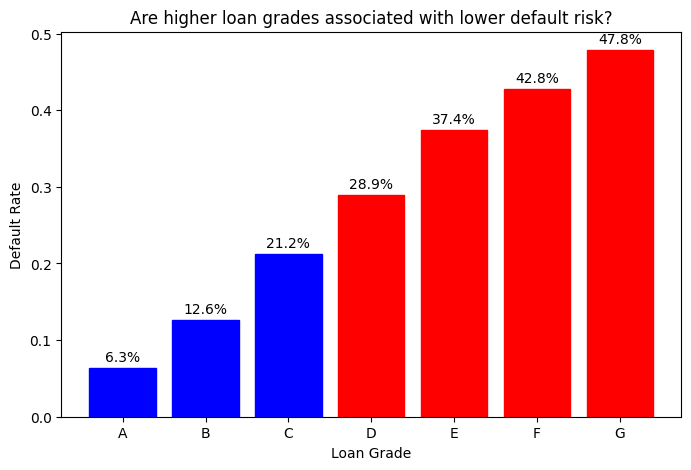

In [ ]:
plt.figure(figsize=(8,5))

grade_default = df.groupby('grade')['default_flag'].mean().sort_index()

bars = plt.bar(grade_default.index, grade_default.values)

# Tô màu
for i, v in enumerate(grade_default.values):
    bars[i].set_color('red' if v > grade_default.mean() else 'blue')

# Thêm % default rate lên trên cột
for i, v in enumerate(grade_default.values):
    plt.text(i, v + 0.005, f'{v*100:.1f}%',
             ha='center', va='bottom')

plt.title("Are higher loan grades associated with lower default risk?")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")

plt.show()

The chart shows a clear and strong upward trend in default rates as loan grades worsen from A to G. Grade A has the lowest default rate at around 5.7%, while it increases steadily to 45.1% for Grade G, indicating a nearly 8x higher risk.

This confirms that loan grade is a highly effective risk indicator, with lower grades (D–G) associated with significantly higher default probability. The sharp increase after Grade C suggests that borrowers in lower-grade segments should be carefully monitored or priced higher due to elevated credit risk.

### 4.3.4. How do loan terms (36 vs 60 months) affect default rates?

<Figure size 600x400 with 0 Axes>

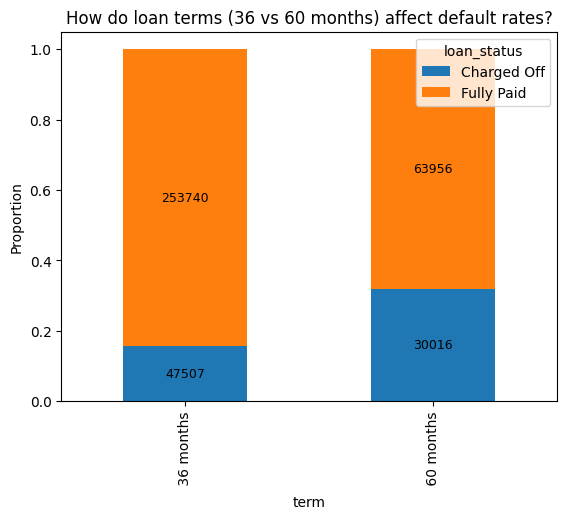

In [ ]:
plt.figure(figsize=(6,4))

term_ct = pd.crosstab(df['term'], df['loan_status'])
term_ratio = pd.crosstab(df['term'], df['loan_status'], normalize='index')

ax = term_ratio.plot(kind='bar', stacked=True)

# Gắn count vào từng phần
for i, term in enumerate(term_ct.index):
    cum_height = 0
    for j, status in enumerate(term_ct.columns):
        count = term_ct.loc[term, status]
        ratio = term_ratio.loc[term, status]

        ax.text(i, cum_height + ratio/2, f'{count}',
                ha='center', va='center', fontsize=9)

        cum_height += ratio

plt.title("How do loan terms (36 vs 60 months) affect default rates?")
plt.ylabel("Proportion")

plt.show()

The chart illustrates a clear positive correlation between loan duration and default risk, as the 60-month term exhibits a significantly higher proportion of "Charged Off" status compared to the 36-month term. Specifically, the default rate for 60-month loans is nearly double that of 36-month loans, suggesting that longer repayment periods carry a substantially higher risk for lenders.

### **Loan and credit attributes influencing default risk**

- Interest rate (int_rate) has the strongest relationship with default, indicating effective risk-based pricing but also reinforcing that higher-cost loans are harder to repay.

- Loan amount (loan_amnt) shows only a weak direct relationship with default, suggesting that loan size alone does not drive risk without considering repayment capacity.
- Income (annual_inc) and DTI (dti) interaction plays a crucial role, where high DTI combined with lower income sharply increases default likelihood.
- Loan purpose (purpose)—especially debt consolidation and credit card repayment—signals higher risk, as these loans are typically used to manage existing liabilities rather than generate new income.
- The overall low correlation among variables suggests that default risk is multidimensional and driven by a combination of borrower characteristics and loan features rather than a single dominant factor.

#  5. Conclusion

1. In terms of borrower profile, default risk is primarily driven by financial pressure, with DTI emerging as the strongest factor, followed by income and loan amount. Borrowers with lower income and higher debt burden are significantly more likely to default. Additionally, loan purpose plays a role, with higher risk observed in categories such as small business and medical loans.

2. High-risk customer segments are characterized by low income, high DTI, and larger loan sizes. These borrowers often lack sufficient repayment capacity, especially when loans are used for uncertain or non-essential purposes. This highlights the need for more careful screening and segmentation in lending decisions.

3. From a strategic perspective, lenders should tighten credit policies by limiting approvals for high-DTI and low-income borrowers, while capping loan amounts based on income levels. Risk-based pricing should be applied, charging higher interest rates for riskier segments such as small business loans. At the same time, safer products like debt consolidation loans can be expanded, while exposure to unsecured business lending should be controlled.